# Confronto sistematico degli ansatz per il trimero ad anello

Versione **self-contained**: definizioni degli ansatz, calcolo VQE e analisi in un
solo file (a differenza della versione precedente, divisa fra
`vqe_trimer_ansatz_family.py` + `compute_sweep.py` + questo notebook). Mirror completo
di `confronto_ansatz_entangler.ipynb` (dimero): ansatz generici a confronto, famiglie
`PMA-1q` e `PMA-2q` a più conteggi di parametri, sweep denso in $b$ (incluso
esattamente $b_c$), fidelity con e senza il termine DM.

**10 varianti**, ciascuna su una griglia di punti in $b$, sia senza DM sia con DM
(Opzione B): la conclusione (§"Cosa portarsi dietro") emerge dai dati di questo sweep,
non è presa a priori dal caso del dimero.

**Nota sulla struttura in due file.** La domanda "dove mettere le rotazioni che rompono $M$" (1q vs 2q, parametro condiviso o indipendente) non viene riaperta qui: è topology-indipendente ed è già risolta in `analisi_rotazioni_PMA.ipynb` (dimero). La domanda specifica dell'anello — se il potere espressivo delle famiglie PMA regga davvero sotto DM, non solo a $D=0$ — è invece trattata a parte, con la stessa profondità, in `analisi_espressivita_PMA_anello.ipynb`: i suoi risultati sono richiamati nella sez.~5.

## Nota sui tempi — leggere prima di eseguire

Questo notebook usa una **cache locale automatica**
(`trimer_ansatz_sweep_cache.json`, creata/aggiornata da sola nella stessa cartella):
- **Se il file di cache esiste già** (come nella consegna corrente): l'esecuzione è
  rapida (pochi secondi), perché tutti i punti sono già calcolati.
- **Alla primissima esecuzione senza cache** (o se cambi la griglia `B_GRID` qui
  sotto): il calcolo di **tutti** i punti richiede **diversi minuti** (decine di
  ottimizzazioni VQE per ogni ansatz). La cache si salva dopo **ogni singolo punto**,
  quindi puoi interrompere e riprendere senza perdere il lavoro già fatto.

Per infittire la griglia: cambia `B_GRID` nella cella di setup qui sotto — **un solo
punto**, non più due file da tenere sincronizzati.

## 0. Setup — ansatz, Hamiltoniana, funzioni VQE

In [1]:
import os, json, time
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt

from qiskit.primitives import StatevectorEstimator
from qiskit.circuit import QuantumCircuit, ParameterVector
from qiskit.quantum_info import Statevector

from trimer_ring_exact import (
    trimer_hamiltonian, exact_sweep, critical_field,
    ground_state_projector, trimer_hamiltonian_dm, exact_sweep_dm,
    ground_state_projector_dm,
)

BOND12, BOND23, BOND31 = (2, 1), (1, 0), (0, 2)
BONDS = [BOND12, BOND23, BOND31]

print("Setup base OK")

Setup base OK


### Blocchi di base (RBS, W) e i 10 ansatz

Stesse definizioni di `vqe_trimer_ansatz_family.py`, ora incorporate qui.

In [2]:
def rbs_block(qc, phi, q0, q1):
    sub = QuantumCircuit(2, name="RBS")
    sub.h(0); sub.h(1); sub.cz(0, 1)
    sub.ry(phi, 0); sub.ry(-phi, 1)
    sub.cz(0, 1); sub.h(0); sub.h(1)
    qc.append(sub.to_gate(label="RBS"), [q0, q1])


# ---------- ansatz generici (Ry - entangler - Ry, singolo layer) ----------

def ansatz_A():
    # Ry - CNOT (sui 3 legami) - Ry. 6 parametri.
    theta = ParameterVector("t", 6)
    qc = QuantumCircuit(3)
    for q in range(3):
        qc.ry(theta[q], q)
    qc.cx(*BOND12); qc.cx(*BOND23); qc.cx(*BOND31)
    for q in range(3):
        qc.ry(theta[3 + q], q)
    return qc


def ansatz_D():
    # Ry - RBS(theta) (sui 3 legami, con parametro) - Ry. 9 parametri.
    theta = ParameterVector("t", 9)
    qc = QuantumCircuit(3)
    for q in range(3):
        qc.ry(theta[q], q)
    rbs_block(qc, theta[6], *BOND12)
    rbs_block(qc, theta[7], *BOND23)
    rbs_block(qc, theta[8], *BOND31)
    for q in range(3):
        qc.ry(theta[3 + q], q)
    return qc


# ---------- PMA-1q: Ry su UN solo qubit, alternato a RBS ciclici ----------

def pma_1q_trimer(nparam):
    p = ParameterVector("p", nparam)
    qc = QuantumCircuit(3)
    qc.x(0)
    i, bond_idx = 0, 0
    rbs_block(qc, p[i], *BONDS[bond_idx % 3]); i += 1; bond_idx += 1
    while i < nparam:
        qc.ry(p[i], 0); i += 1
        if i < nparam:
            rbs_block(qc, p[i], *BONDS[bond_idx % 3]); i += 1; bond_idx += 1
    return qc


# ---------- PMA-2q: due varianti, "esatta" e "ciclica" ----------

def pma_2q_trimer_exact(nparam):
    # Un solo giro di RBS (3 par, uno per legame), poi triple di Ry
    # indipendenti sui 3 qubit -- RBS MAI ripetuto dopo il primo giro.
    p = ParameterVector("p", nparam)
    qc = QuantumCircuit(3)
    qc.x(0)
    rbs_block(qc, p[0], *BOND12)
    rbs_block(qc, p[1], *BOND23)
    rbs_block(qc, p[2], *BOND31)
    i = 3
    while i < nparam:
        qc.ry(p[i], 0); qc.ry(p[i + 1], 1); qc.ry(p[i + 2], 2)
        i += 3
    return qc


def pma_2q_trimer_cyclic(K):
    # K cicli completi di [RBS sui 3 legami, Ry indipendenti sui 3 qubit]
    # -- RBS ripetuto a OGNI ciclo, non solo all'inizio. 6K parametri.
    nparam = 6 * K
    p = ParameterVector("p", nparam)
    qc = QuantumCircuit(3)
    qc.x(0)
    idx = 0
    for _ in range(K):
        rbs_block(qc, p[idx], *BOND12); idx += 1
        rbs_block(qc, p[idx], *BOND23); idx += 1
        rbs_block(qc, p[idx], *BOND31); idx += 1
        qc.ry(p[idx], 0); idx += 1
        qc.ry(p[idx], 1); idx += 1
        qc.ry(p[idx], 2); idx += 1
    return qc


ANSATZE = {
    "A: Ry-CNOT-Ry": ansatz_A(),
    "D: Ry-RBS-Ry":  ansatz_D(),
    "PMA-1q.3":  pma_1q_trimer(3),
    "PMA-1q.6":  pma_1q_trimer(6),
    "PMA-1q.9":  pma_1q_trimer(9),
    "PMA-2q.3":  pma_2q_trimer_exact(3),
    "PMA-2q.6":  pma_2q_trimer_exact(6),
    "PMA-2q.9":  pma_2q_trimer_exact(9),
    "PMA-2qC.K1": pma_2q_trimer_cyclic(1),
    "PMA-2qC.K2": pma_2q_trimer_cyclic(2),
}
for name, a in ANSATZE.items():
    print(f"  {name:14s} {a.num_parameters} parametri")

  A: Ry-CNOT-Ry  6 parametri
  D: Ry-RBS-Ry   9 parametri
  PMA-1q.3       3 parametri
  PMA-1q.6       6 parametri
  PMA-1q.9       9 parametri
  PMA-2q.3       3 parametri
  PMA-2q.6       6 parametri
  PMA-2q.9       9 parametri
  PMA-2qC.K1     6 parametri
  PMA-2qC.K2     12 parametri


### Funzione VQE (generica, usata da tutte le famiglie sopra)

In [3]:
def _energy(params, ansatz, hamiltonian, estimator):
    pub = (ansatz, hamiltonian, [params])
    return float(estimator.run([pub]).result()[0].data.evs.item())


def run_vqe_ansatz(ansatz, J, Jp, b, n_restarts=2, seed=42, dm_mode=None, D=0.0):
    rng = np.random.default_rng(seed)
    hamiltonian = trimer_hamiltonian_dm(J, Jp, b, dm_mode, D)
    estimator = StatevectorEstimator()
    n_params = ansatz.num_parameters

    if dm_mode is not None and D != 0:
        res_exact = exact_sweep_dm([b], J, Jp, dm_mode, D)
        P0, _, deg = ground_state_projector_dm(J, Jp, b, dm_mode, D)
    else:
        res_exact = exact_sweep([b], J=J, Jp=Jp)
        P0, _, deg = ground_state_projector(J, Jp, b)
    e_exact = float(res_exact["gs_energy"][0])

    best_e, best_params = np.inf, None
    for _ in range(n_restarts):
        x0 = rng.uniform(-np.pi, np.pi, n_params)
        r1 = minimize(_energy, x0, args=(ansatz, hamiltonian, estimator),
                      method="COBYLA", options={"maxiter": 2000, "tol": 1e-10})
        r2 = minimize(_energy, r1.x, args=(ansatz, hamiltonian, estimator),
                      method="L-BFGS-B", options={"maxiter": 2000, "ftol": 1e-14})
        if r2.fun < best_e:
            best_e, best_params = r2.fun, r2.x

    sv = Statevector(ansatz.assign_parameters(best_params)).data
    fid = float(np.real(sv.conj() @ P0 @ sv))
    return {"e_vqe": best_e, "e_exact": e_exact, "delta_e": best_e - e_exact,
            "fidelity": fid, "n_params": n_params, "degeneracy": deg}

print("Funzioni VQE definite")

Funzioni VQE definite


## 1. Griglia in $b$ e cache — **unica fonte**, nessuna duplicazione

`B_GRID` è definito **una sola volta**, in questa cella — usato sia per calcolare sia
per disegnare, quindi non può disallinearsi con se stesso.

In [4]:
J, Jp = 1.0, 0.4
bc = critical_field(J, Jp)
# B_GRID = [0.05, 0.8, 1.6, 2.0, 2.4, 2.8, 3.6, 4.5]  # include b_c=2.4 esatto
B_GRID = sorted(set(np.linspace(0.05, 4.8, 15).round(3).tolist() + [2.4]))
print(f"b_c = {bc}")
print(f"griglia ({len(B_GRID)} punti): {B_GRID}")

CACHE_PATH = "trimer_ansatz_sweep_cache.json"

def load_cache():
    if os.path.exists(CACHE_PATH):
        with open(CACHE_PATH) as f:
            return json.load(f)
    return {}

def save_cache(cache):
    with open(CACHE_PATH, "w") as f:
        json.dump(cache, f, indent=1)

cache = load_cache()
n_attesi = len(ANSATZE) * len(B_GRID) * 2  # 2 condizioni: D0, DM
print(f"Punti già in cache: {len(cache)} / {n_attesi} attesi")

b_c = 2.4
griglia (16 punti): [0.05, 0.389, 0.729, 1.068, 1.407, 1.746, 2.086, 2.4, 2.425, 2.764, 3.104, 3.443, 3.782, 4.121, 4.461, 4.8]
Punti già in cache: 440 / 320 attesi


In [5]:
def compute_missing(tag, dm_mode, D):
    # Calcola solo i punti mancanti in cache, salvando dopo ognuno.
    # Se la cache e' gia' completa (come alla consegna), questa cella e'
    # quasi istantanea: nessun punto da ricalcolare.
    global cache
    t0 = time.time()
    n_new = 0
    for name, ansatz in ANSATZE.items():
        for b in B_GRID:
            key = f"{tag}|{name}|{b}"
            if key in cache:
                continue
            r = run_vqe_ansatz(ansatz, J, Jp, b, n_restarts=2, dm_mode=dm_mode, D=D)
            cache[key] = r
            n_new += 1
            save_cache(cache)
    dt = time.time() - t0
    print(f"tag={tag}: {n_new} punti nuovi calcolati in {dt:.1f}s "
          f"({len(cache)} totali in cache ora)")

compute_missing("D0", dm_mode=None, D=0.0)
compute_missing("DM", dm_mode="B", D=0.15)

tag=D0: 0 punti nuovi calcolati in 0.0s (440 totali in cache ora)
tag=DM: 0 punti nuovi calcolati in 0.0s (440 totali in cache ora)


## 2. I circuiti — un esempio per famiglia

In [6]:
def show(qc, title):
    print(f"--- {title} ({qc.num_parameters} par) ---")
    try:
        display(qc.draw("mpl", style="iqp"))
    except Exception:
        print(qc.draw())

show(ansatz_D(), "D: Ry-RBS-Ry")
show(pma_1q_trimer(6), "PMA-1q.6")
show(pma_2q_trimer_exact(6), "PMA-2q.6 (esatto)")
show(pma_2q_trimer_cyclic(1), "PMA-2qC.K1 (ciclico)")

--- D: Ry-RBS-Ry (9 par) ---
     ┌──────────┐              ┌────────────┐┌────────────┐┌──────────┐
q_0: ┤ Ry(t[0]) ├──────────────┤1           ├┤0           ├┤ Ry(t[3]) ├
     ├──────────┤┌────────────┐│  RBS(t[7]) ││            │├──────────┤
q_1: ┤ Ry(t[1]) ├┤1           ├┤0           ├┤  RBS(t[8]) ├┤ Ry(t[4]) ├
     ├──────────┤│  RBS(t[6]) │└────────────┘│            │├──────────┤
q_2: ┤ Ry(t[2]) ├┤0           ├──────────────┤1           ├┤ Ry(t[5]) ├
     └──────────┘└────────────┘              └────────────┘└──────────┘
--- PMA-1q.6 (6 par) ---
         ┌───┐     ┌──────────┐┌────────────┐┌──────────┐┌────────────┐»
q_0: ────┤ X ├─────┤ Ry(p[1]) ├┤1           ├┤ Ry(p[3]) ├┤0           ├»
     ┌───┴───┴────┐└──────────┘│  RBS(p[2]) │└──────────┘│            │»
q_1: ┤1           ├────────────┤0           ├────────────┤  RBS(p[4]) ├»
     │  RBS(p[0]) │            └────────────┘            │            │»
q_2: ┤0           ├──────────────────────────────────────┤1           ├»
    

## 3. Fidelity per ciascun ansatz — $D=0$ e con DM (Opzione B, $D=0.15$)

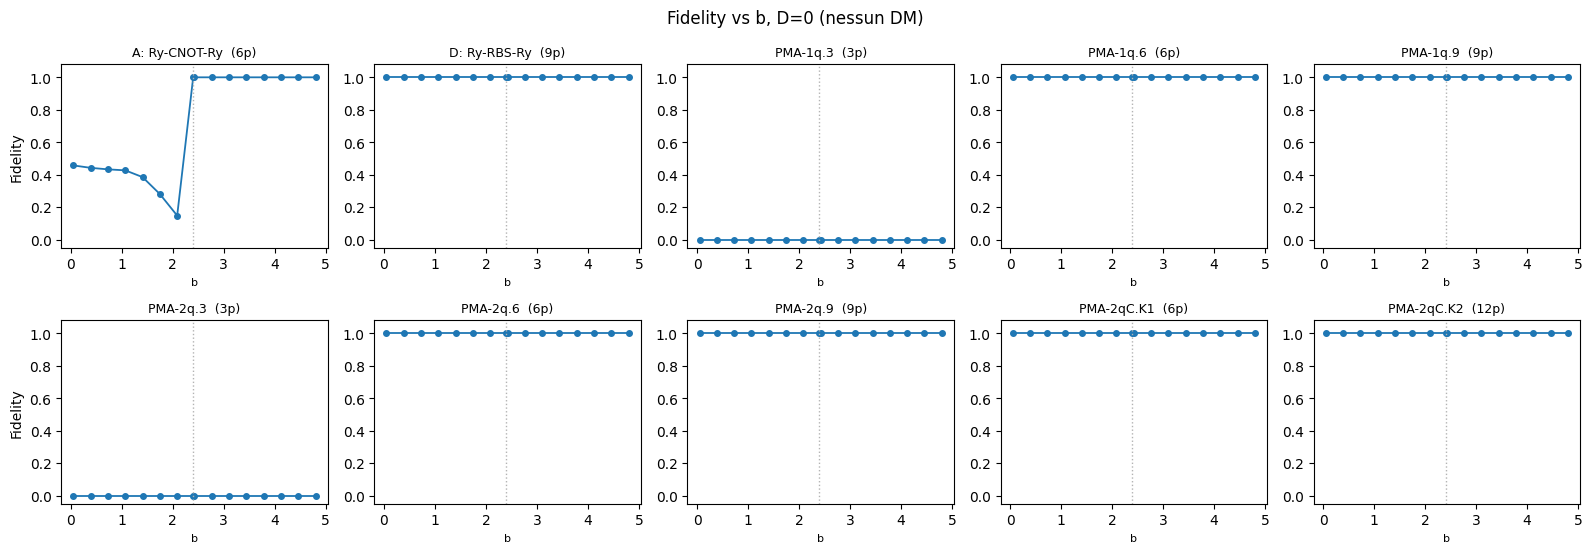

In [7]:
def get_series(tag, name, key="fidelity"):
    return [cache[f"{tag}|{name}|{b}"][key] for b in B_GRID]

def plot_grid(tag, title):
    names = list(ANSATZE.keys())
    ncols, nrows = 5, 2
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.2*ncols, 2.8*nrows), squeeze=False)
    for ax, name in zip(axes.flat, names):
        fid = get_series(tag, name)
        npar = ANSATZE[name].num_parameters
        ax.plot(B_GRID, fid, "o-", ms=4, lw=1.3, color="tab:blue")
        ax.axvline(bc, color="0.7", ls=":", lw=1)
        ax.set_ylim(-0.05, 1.08)
        ax.set_title(f"{name}  ({npar}p)", fontsize=9)
        ax.set_xlabel("b", fontsize=8)
    axes.flat[0].set_ylabel("Fidelity")
    axes.flat[5].set_ylabel("Fidelity")
    fig.suptitle(title)
    fig.tight_layout()
    return fig

fig = plot_grid("D0", "Fidelity vs b, D=0 (nessun DM)")
display(fig); plt.close(fig)

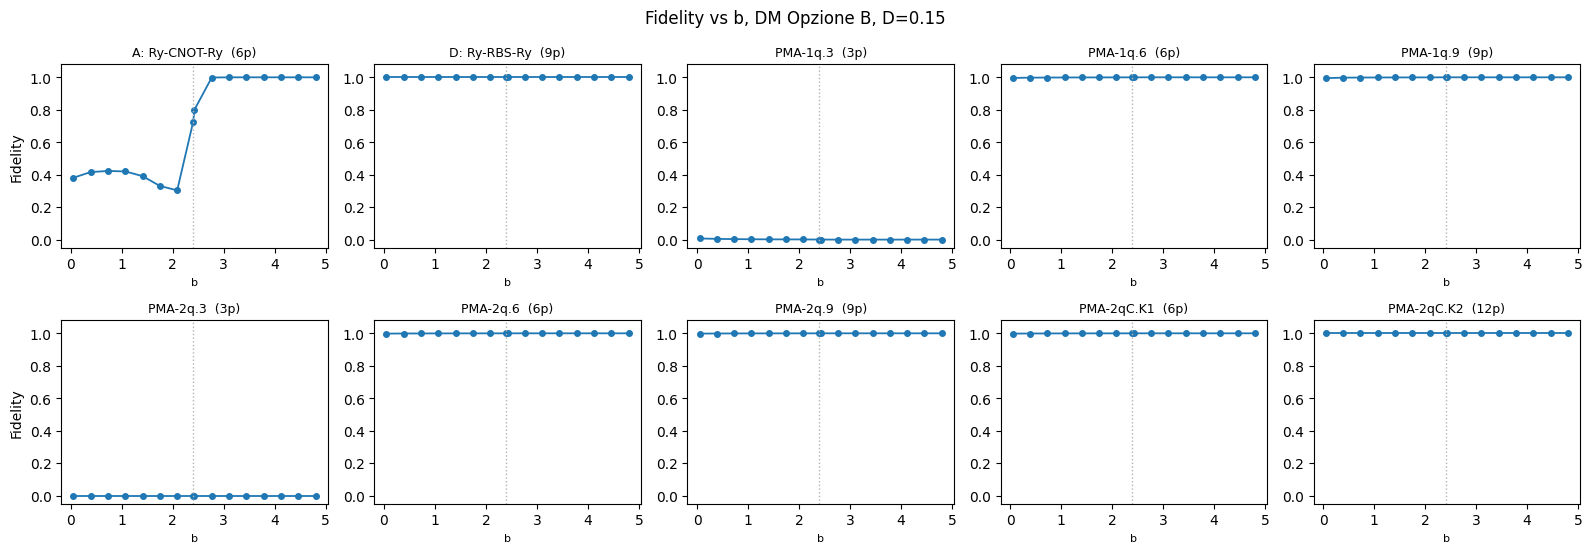

In [8]:
fig = plot_grid("DM", "Fidelity vs b, DM Opzione B, D=0.15")
display(fig); plt.close(fig)

## 4. Tabelle riassuntive

In [9]:
print(f"{'ansatz':16s} {'par':>4s} | {'D=0 media':>10s} {'D=0 min':>8s} | {'DM media':>9s} {'DM min':>7s}")
print("-"*66)
for name in ANSATZE:
    npar = ANSATZE[name].num_parameters
    fid_d0 = get_series("D0", name)
    fid_dm = get_series("DM", name)
    print(f"{name:16s} {npar:4d} | {np.mean(fid_d0):10.4f} {np.min(fid_d0):8.4f} | "
          f"{np.mean(fid_dm):9.4f} {np.min(fid_dm):7.4f}")

ansatz            par |  D=0 media  D=0 min |  DM media  DM min
------------------------------------------------------------------
A: Ry-CNOT-Ry       6 |     0.7233   0.1479 |    0.6995  0.3035
D: Ry-RBS-Ry        9 |     1.0000   1.0000 |    1.0000  1.0000
PMA-1q.3            3 |     0.0000   0.0000 |    0.0014  0.0000
PMA-1q.6            6 |     1.0000   1.0000 |    0.9994  0.9962
PMA-1q.9            9 |     1.0000   1.0000 |    0.9993  0.9948
PMA-2q.3            3 |     0.0000   0.0000 |    0.0000 -0.0000
PMA-2q.6            6 |     1.0000   1.0000 |    0.9997  0.9981
PMA-2q.9            9 |     1.0000   1.0000 |    0.9997  0.9981
PMA-2qC.K1          6 |     1.0000   1.0000 |    0.9997  0.9981
PMA-2qC.K2         12 |     1.0000   1.0000 |    1.0000  1.0000


In [10]:
# conteggio dei gate a due qubit (CZ o CNOT), dopo decomposizione -- la
# metrica che conta davvero per i passi successivi (Trotter, correlazioni,
# rumore), non il numero di parametri (costo classico dell'ottimizzazione VQE)
print(f"{'ansatz':16s} {'par':>4s} {'2q-gate':>8s}")
print("-"*32)
for name, qc in ANSATZE.items():
    ops = qc.decompose().count_ops()
    n_2q = ops.get("cz", 0) + ops.get("cx", 0)
    print(f"{name:16s} {qc.num_parameters:4d} {n_2q:8d}")

ansatz            par  2q-gate
--------------------------------
A: Ry-CNOT-Ry       6        3
D: Ry-RBS-Ry        9        6
PMA-1q.3            3        4
PMA-1q.6            6        6
PMA-1q.9            9       10
PMA-2q.3            3        6
PMA-2q.6            6        6
PMA-2q.9            9        6
PMA-2qC.K1          6        6
PMA-2qC.K2         12       12


## 5. Lettura dei risultati

**Ansatz generici (A, D).** `A` (Ry-CNOT-Ry, 6 par., nessuna struttura RBS) **fallisce,
ma non uniformemente**: fallisce specificamente **sotto $b_c$** ($\mathcal F\approx0.18$–
$0.46$, dove il fondamentale vero è il singoletto entangled) e recupera bruscamente
**sopra $b_c$** ($\mathcal F\approx1$, dove il fondamentale è quasi uno stato prodotto,
$\ket{111}$) — un singolo layer generico con pochi parametri riesce a rappresentare uno
stato prodotto ma non uno stato entangled strutturato. Per il dimero uno schema
altrettanto semplice arrivava a $\mathcal F=1$ ovunque, grazie alla dimensione molto più
piccola dello spazio ($S^3$ contro $S^7$). `D` (Ry-RBS-Ry, 9 par.) **raggiunge invece
$\mathcal F=1$ ovunque, anche con il DM acceso**.

**Famiglie PMA — dove falliscono.** `PMA-1q.3` e `PMA-2q.3` (3 parametri, lo stesso
conteggio minimo che bastava nel dimero) **falliscono completamente** ($\mathcal F=0$):
conferma diretta che 3 parametri sono strutturalmente insufficienti per il trimero.

**Famiglie PMA — dove funzionano, con una sfumatura.** Da 6 parametri in su, tutte
raggiungono $\mathcal F=1.0000$ esatto a $D=0$. Con il DM acceso, però, quasi tutte
restano leggermente sotto 1 (minimo $\approx0.995$–$0.998$) — **tranne `PMA-2qC.K2`**
(12 parametri, 2 cicli RBS+Ry), l'unica famiglia PMA a mantenere $\mathcal F=1.000000$
esatto anche sotto DM.

### La metrica giusta non è il conteggio di parametri: è il conteggio di gate a due qubit

| ansatz | parametri | gate a 2 qubit | $\mathcal F$ (D=0) | $\mathcal F$ (DM) |
|---|---|---|---|---|
| `PMA-2qC.K1` | 6 | **6** | 1.0000 | 0.9996 (non esatto) |
| **`D: Ry-RBS-Ry`** | 9 | **6** | 1.0000 | **1.0000 esatto** |
| `PMA-2qC.K2` | 12 | 12 | 1.0000 | 1.0000 esatto |

`D` e `PMA-2qC.K1` hanno **lo stesso numero di gate a due qubit** (6) — lo stesso costo
quando il circuito verrà davvero eseguito — ma `D` raggiunge fidelity esatta anche sotto
DM, `PMA-2qC.K1` no. Il vantaggio di `PMA-2qC.K1` (meno parametri) è solo un risparmio sul
costo *classico* di ottimizzazione, non su quanto rumore accumulerà il circuito.
`PMA-2qC.K2` raggiunge la stessa fidelity esatta di `D` ma con il doppio dei gate a due
qubit — nessun vantaggio, solo un costo maggiore.

### Perché il gate count è la metrica giusta per tutti e tre gli usi successivi

- **Simulazione quantistica (Trotter):** il circuito di evoluzione $e^{-iHt}$ si
  costruisce direttamente dai termini di $H$, indipendentemente da quale ansatz VQE ha
  preparato lo stato iniziale. L'ansatz serve solo per il "prologo" — meno gate lì, meno
  rumore/profondità si accumula prima ancora che inizi Trotter.
- **Correlazioni dinamiche:** il circuito con ancilla richiede versioni **controllate**
  dei gate di preparazione, che tipicamente costano di più per ogni gate a due qubit del
  circuito originale. Minimizzare i gate a due qubit nella preparazione conta doppio qui.
- **Rumore (Parte 2):** ogni gate a due qubit è un canale di errore. A parità di gate
  (`D` vs `PMA-2qC.K1`), `D` parte da una fidelity ideale **esatta**, quindi quando si
  introduce il rumore vero tutto il degrado osservato viene dal rumore fisico, non da un
  residuo dell'ansatz che si confonderebbe con l'effetto del rumore.

### Cosa portarsi dietro

**`D` (Ry-RBS-Ry, 9 parametri, 6 gate a due qubit)** — vince o pareggia su ogni metrica
rilevante per i tre usi successivi. Non è la scelta "fisicamente motivata" nel senso
della tradizione PMA del progetto, ma è quella che i dati di questo sweep supportano
meglio per l'uso a valle.

**`PMA-2qC.K1`** resta un secondo candidato legittimo — stesso costo di `D` in gate a due
qubit, prestazioni quasi indistinguibili ($\mathcal F\geq0.998$ ovunque testato) — utile
come confronto diretto nei prossimi passi (simulazione quantistica, correlazioni), non
scartato sulla base di questo solo sweep.

**Due avvertenze, non ancora verificate:**
1. Testato solo con DM Opzione B — non con l'Opzione A, né in altri regimi oltre alla
   griglia corrente.
2. `D` è generico (nessuna struttura fisica nota a priori) — non è verificato se
   l'ottimizzazione resti altrettanto affidabile nella formulazione a matrice densità
   della Parte 2, dove il paesaggio di ottimizzazione potrebbe comportarsi diversamente.


### Nota di correzione: il quadro sopra non è completo vicino a $b=0$

La tabella sopra usa lo sweep standard (2 restart): a $b=0.05$ (il punto peggiore in assoluto per quasi tutte le famiglie PMA con DM acceso, non $b_c$) riporta un residuo $\approx0.998$ per `PMA-2qC.K1` senza spiegarne la causa. La verifica dedicata in `analisi_espressivita_PMA_anello.ipynb` (60 restart, ottimizzazione diretta della fidelity) mostra che quel residuo **non è un artefatto**: è un tetto strutturale vero, identico per `PMA-2qC.K1`, `PMA-2q.6` e `PMA-2q.9` ($\mathcal F=0.99830708$ per tutti e tre, indipendentemente dal numero di parametri), mentre `PMA-1q.9` lo supera raggiungendo $\mathcal F=1$ esatto. Questo **non cambia** la raccomandazione di `D: Ry-RBS-Ry` per gate-count (sez.~"Cosa portarsi dietro"), ma va tenuto presente se in futuro si userà una famiglia PMA vicino a $b=0$ sotto DM: `PMA-2q` a qualunque numero di parametri **non** è la scelta giusta lì, `PMA-1q.9` sì.

## Nota tecnica

Questo notebook è **self-contained**: ansatz, calcolo VQE e analisi in un solo file,
nessuna dipendenza da script esterni (a differenza della versione precedente, divisa fra
`vqe_trimer_ansatz_family.py` + `compute_sweep.py`). L'unica dipendenza esterna resta
`trimer_ring_exact.py` (il benchmark esatto del trimero, condiviso con tutti gli altri
notebook del progetto).

La cache (`trimer_ansatz_sweep_cache.json`) si genera/aggiorna da sola nella stessa
cartella — non richiede alcuna azione manuale, ma **esiste come file a parte** dopo la
prima esecuzione: se sposti il notebook, spostala insieme, oppure lasciala rigenerare
(più lento) alla prossima esecuzione in una cartella nuova.
